In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

DATA_DIR = './data'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')

def count_files(directory):
    files = os.listdir(directory)
    return len(files)

print(f"Train Images: {count_files(os.path.join(TRAIN_DIR, 'images'))}")
print(f"Train Labels: {count_files(os.path.join(TRAIN_DIR, 'labels'))}")

Train Images: 5598
Train Labels: 5598


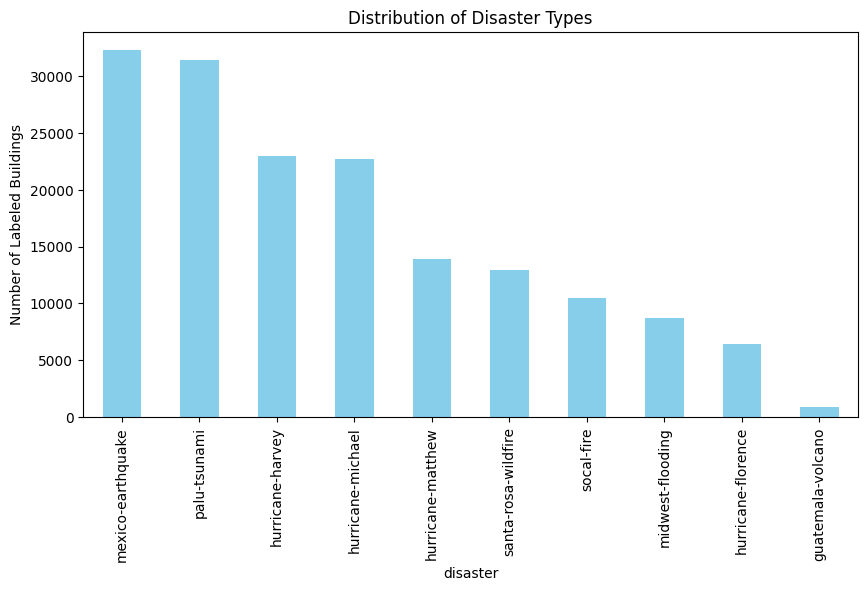

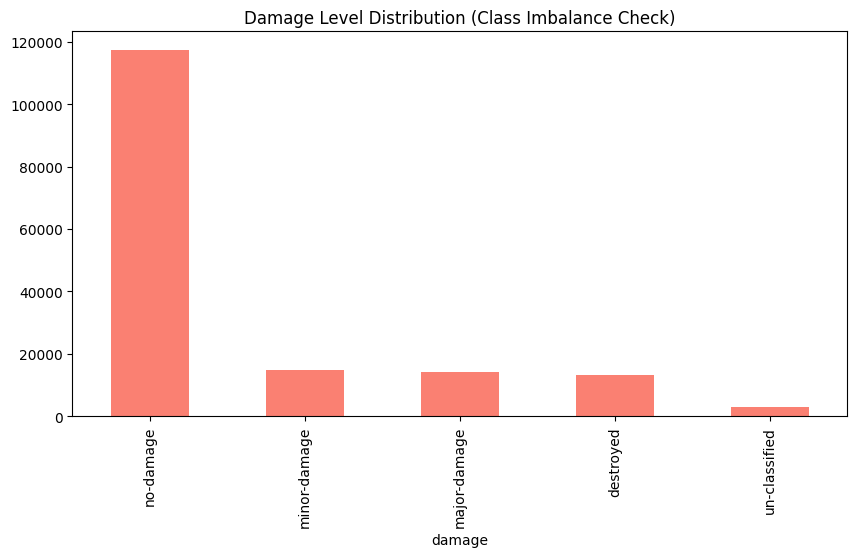

In [ ]:
results = []
label_path = os.path.join(TRAIN_DIR, 'labels')

for filename in os.listdir(label_path):
    if '_post_disaster.json' in filename:
        with open(os.path.join(label_path, filename)) as f:
            data = json.load(f)
            
        disaster_type = filename.split('_')[0]
        
        # Extract damage levels for every building in this image
        for building in data['features']['xy']:
            damage = building['properties'].get('subtype', 'no-damage')
            results.append({'disaster': disaster_type, 'damage': damage})

df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
df['disaster'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Disaster Types')
plt.ylabel('Number of Labeled Buildings')
plt.show()

plt.figure(figsize=(10, 5))
df['damage'].value_counts().plot(kind='bar', color='salmon')
plt.title('Damage Level Distribution (Class Imbalance Check)')
plt.show()

In [7]:
df = pd.DataFrame(data)
df.head()

,features,metadata
lng_lat,[],NaN
xy,[],NaN
sensor,NaN,WORLDVIEW02
provider_asset_type,NaN,WORLDVIEW02
gsd,NaN,2.570075


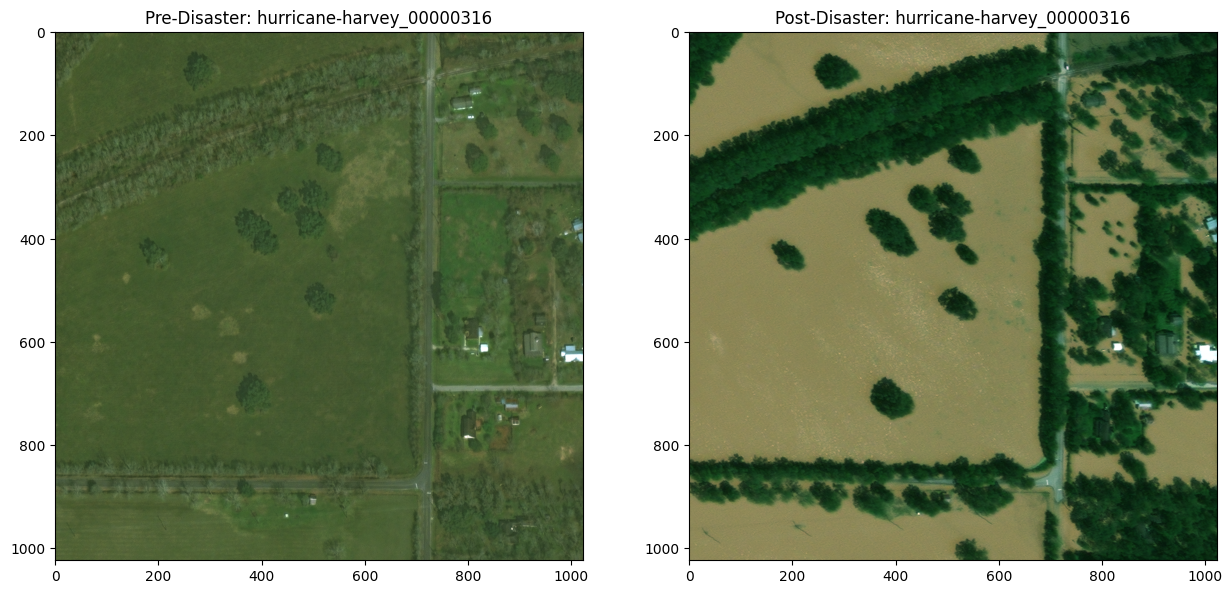

In [ ]:
def plot_sample(sample_id):
    pre_img = Image.open(os.path.join(TRAIN_DIR, 'images', f"{sample_id}_pre_disaster.png"))
    post_img = Image.open(os.path.join(TRAIN_DIR, 'images', f"{sample_id}_post_disaster.png"))
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].imshow(pre_img)
    ax[0].set_title(f"Pre-Disaster: {sample_id}")
    ax[1].imshow(post_img)
    ax[1].set_title(f"Post-Disaster: {sample_id}")
    plt.show()

plot_sample('hurricane-harvey_00000316')

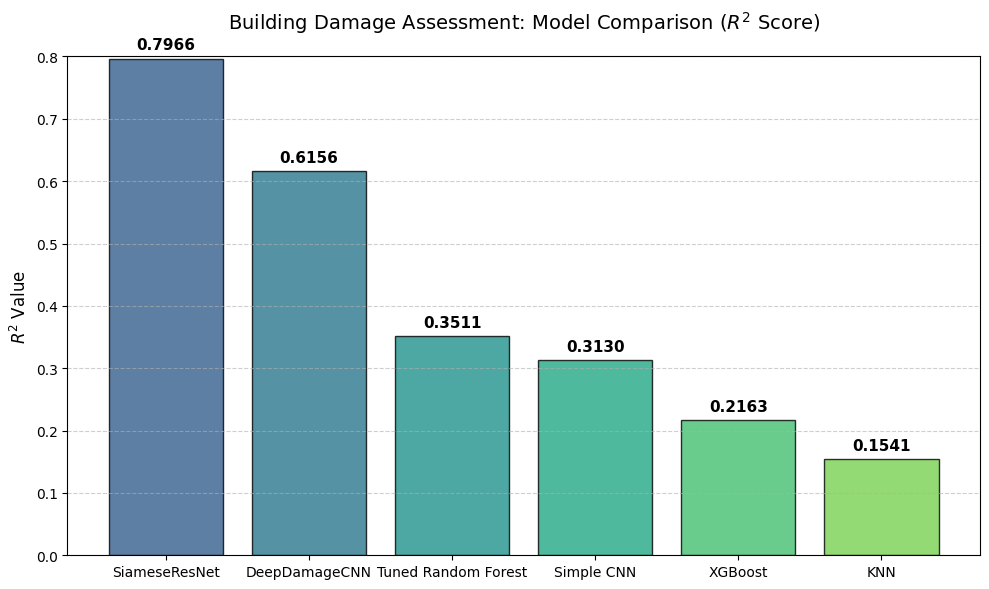

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    'Tuned Random Forest', 
    'XGBoost', 
    'KNN', 
    'Simple CNN', 
    'DeepDamageCNN',
    'SiameseResNet'
]

r2_values = [
    0.3511,  # Tuned Random Forest [from user text]
    0.2163,  # XGBoost [from baseline_model_results.png]
    0.1541,  # KNN [from baseline_model_results.png]
    0.3130,  # Simple CNN [from user text]
    0.6156,   # DeepDamageCNN [from baseline_model_results.png]
    0.7966
]

data = sorted(zip(models, r2_values), key=lambda x: x[1], reverse=True)
sorted_models, sorted_r2 = zip(*data)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(sorted_models)))

bars = plt.bar(sorted_models, sorted_r2, color=colors, edgecolor='black', alpha=0.8)

plt.title(r'Building Damage Assessment: Model Comparison ($R^2$ Score)', fontsize=14, pad=20)
plt.ylabel(r'$R^2$ Value', fontsize=12)
plt.ylim(0, 0.8)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')


plt.tight_layout()
plt.show()

In [2]:
import torch

DEVICE = torch.device("xpu") if torch.cuda.is_available() or hasattr(torch, "xpu") else torch.device("cpu")
if hasattr(torch, "xpu"):
    print(f"✨ Using Intel Arc GPU acceleration ({torch.xpu.get_device_name()})")

✨ Using Intel Arc GPU acceleration (Intel(R) Graphics [0x64a0])


In [ ]:
import cv2
from tqdm import tqdm
from shapely import wkt
from shapely.geometry import Polygon

PATCH_SIZE = 128 
TRAIN_IMG_DIR = './data/train/images'
TRAIN_LBL_DIR = './data/train/labels'

DAMAGE_MAP = {
    "no-damage": 0.0,
    "minor-damage": 0.33,
    "major-damage": 0.66,
    "destroyed": 1.0,
    "un-classified": None 
}

def get_building_patches(limit_images=50):
    x_pre, x_post, y = [], [], []
    
    label_files = [f for f in os.listdir(TRAIN_LBL_DIR) if '_post_disaster.json' in f][:limit_images]

    for label_file in tqdm(label_files, desc="Processing Images"):
        with open(os.path.join(TRAIN_LBL_DIR, label_file)) as f:
            label_data = json.load(f)
            
        base_id = label_file.replace('_post_disaster.json', '')
        pre_path = os.path.join(TRAIN_IMG_DIR, f"{base_id}_pre_disaster.png")
        post_path = os.path.join(TRAIN_IMG_DIR, f"{base_id}_post_disaster.png")
        
        if not os.path.exists(pre_path) or not os.path.exists(post_path):
            continue
            
        img_pre = cv2.imread(pre_path)
        img_post = cv2.imread(post_path)

        for feature in label_data['features']['xy']:
            damage_str = feature['properties'].get('subtype', 'un-classified')
            target_val = DAMAGE_MAP.get(damage_str)
            
            if target_val is None:
                continue
            
            poly = wkt.loads(feature['wkt'])
            centroid = poly.centroid
            cx, cy = int(centroid.x), int(centroid.y)
            
            half_size = PATCH_SIZE // 2
            
            # Ensure crop stays within image boundaries
            if (cy - half_size > 0 and cy + half_size < 1024 and 
                cx - half_size > 0 and cx + half_size < 1024):
                
                patch_pre = img_pre[cy-half_size:cy+half_size, cx-half_size:cx+half_size]
                patch_post = img_post[cy-half_size:cy+half_size, cx-half_size:cx+half_size]
                
                x_pre.append(patch_pre)
                x_post.append(patch_post)
                y.append(target_val)

    return np.array(x_pre), np.array(x_post), np.array(y)

print("Starting patch extraction...")
X_pre, X_post, y_train = get_building_patches(limit_images=100) 
print(f"Extracted {len(y_train)} building patches.")

Starting patch extraction...


Processing Images: 100%|██████████| 100/100 [00:04<00:00, 20.87it/s]


Extracted 4642 building patches.


In [ ]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, f1_score, confusion_matrix
from scipy.stats import spearmanr

# Importing shared logic from resnet script
# Ensure the file is named siamese_resnet_optimized.py in your directory
from resnet import SiameseResNet, SiameseLazyDataset, get_metadata, DEVICE, DAMAGE_MAP, PATCH_SIZE

WEIGHTS_PATH = 'best_siamese_resnet.pth'
LIMIT_IMAGES = 1200 

print(f"🚀 Initializing Analysis on {DEVICE}...")

metadata, _ = get_metadata(limit=LIMIT_IMAGES)

model = SiameseResNet().to(DEVICE)
try:
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
    print("✅ Weights loaded successfully.")
except FileNotFoundError:
    print(f"❌ Error: {WEIGHTS_PATH} not found. Ensure training completed first.")

model.eval()

🚀 Initializing Analysis on xpu...


Scanning Metadata: 100%|██████████| 500/500 [00:00<00:00, 1093.22it/s]


📈 Dataset Imbalance: {0.0: 12717, 0.33: 1170, 0.66: 1890, 1.0: 889}
✅ Weights loaded successfully.


SiameseResNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [ ]:
ds = SiameseLazyDataset(metadata, transform=None)
loader = DataLoader(ds, batch_size=16, shuffle=False, num_workers=4)

all_preds = []
all_targets = []

with torch.no_grad():
    for pre, post, target in tqdm(loader, desc="Running Inference"):
        pre, post = pre.to(DEVICE), post.to(DEVICE)
        out = model(pre, post).cpu().numpy().flatten()
        all_preds.extend(out)
        all_targets.extend(target.numpy().flatten())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

Running Inference: 100%|██████████| 1042/1042 [04:53<00:00,  3.55it/s]


In [ ]:
r2 = r2_score(all_targets, all_preds)
mae = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
rho, _ = spearmanr(all_targets, all_preds)

def get_label_name(val):
    if val < 0.165: return "No Damage"
    if val < 0.495: return "Minor"
    if val < 0.825: return "Major"
    return "Destroyed"

target_labels = [get_label_name(t) for t in all_targets]
pred_labels = [get_label_name(p) for p in all_preds]

binned_f1 = f1_score(target_labels, pred_labels, average='macro')

print("\n" + "="*50)
print(f"{'REGRESSION METRIC':<25} | {'VALUE':<10}")
print("-" * 50)
print(f"{'R-squared (Global)':<25} | {r2:.4f}")
print(f"{'Mean Absolute Error':<25} | {mae:.4f}")
print(f"{'Root Mean Square Error':<25} | {rmse:.4f}")
print(f"{'Spearman Correlation':<25} | {rho:.4f}")
print("-" * 50)
print(f"{'BINNED CLASSIFICATION':<25} | {'VALUE':<10}")
print(f"{'Macro-F1 Score':<25} | {binned_f1:.4f}")
print("="*50)



REGRESSION METRIC         | VALUE     
--------------------------------------------------
R-squared (Global)        | -0.7571
Mean Absolute Error       | 0.3025
Root Mean Square Error    | 0.3921
Spearman Correlation      | 0.2915
--------------------------------------------------
BINNED CLASSIFICATION     | VALUE     
Macro-F1 Score            | 0.3150


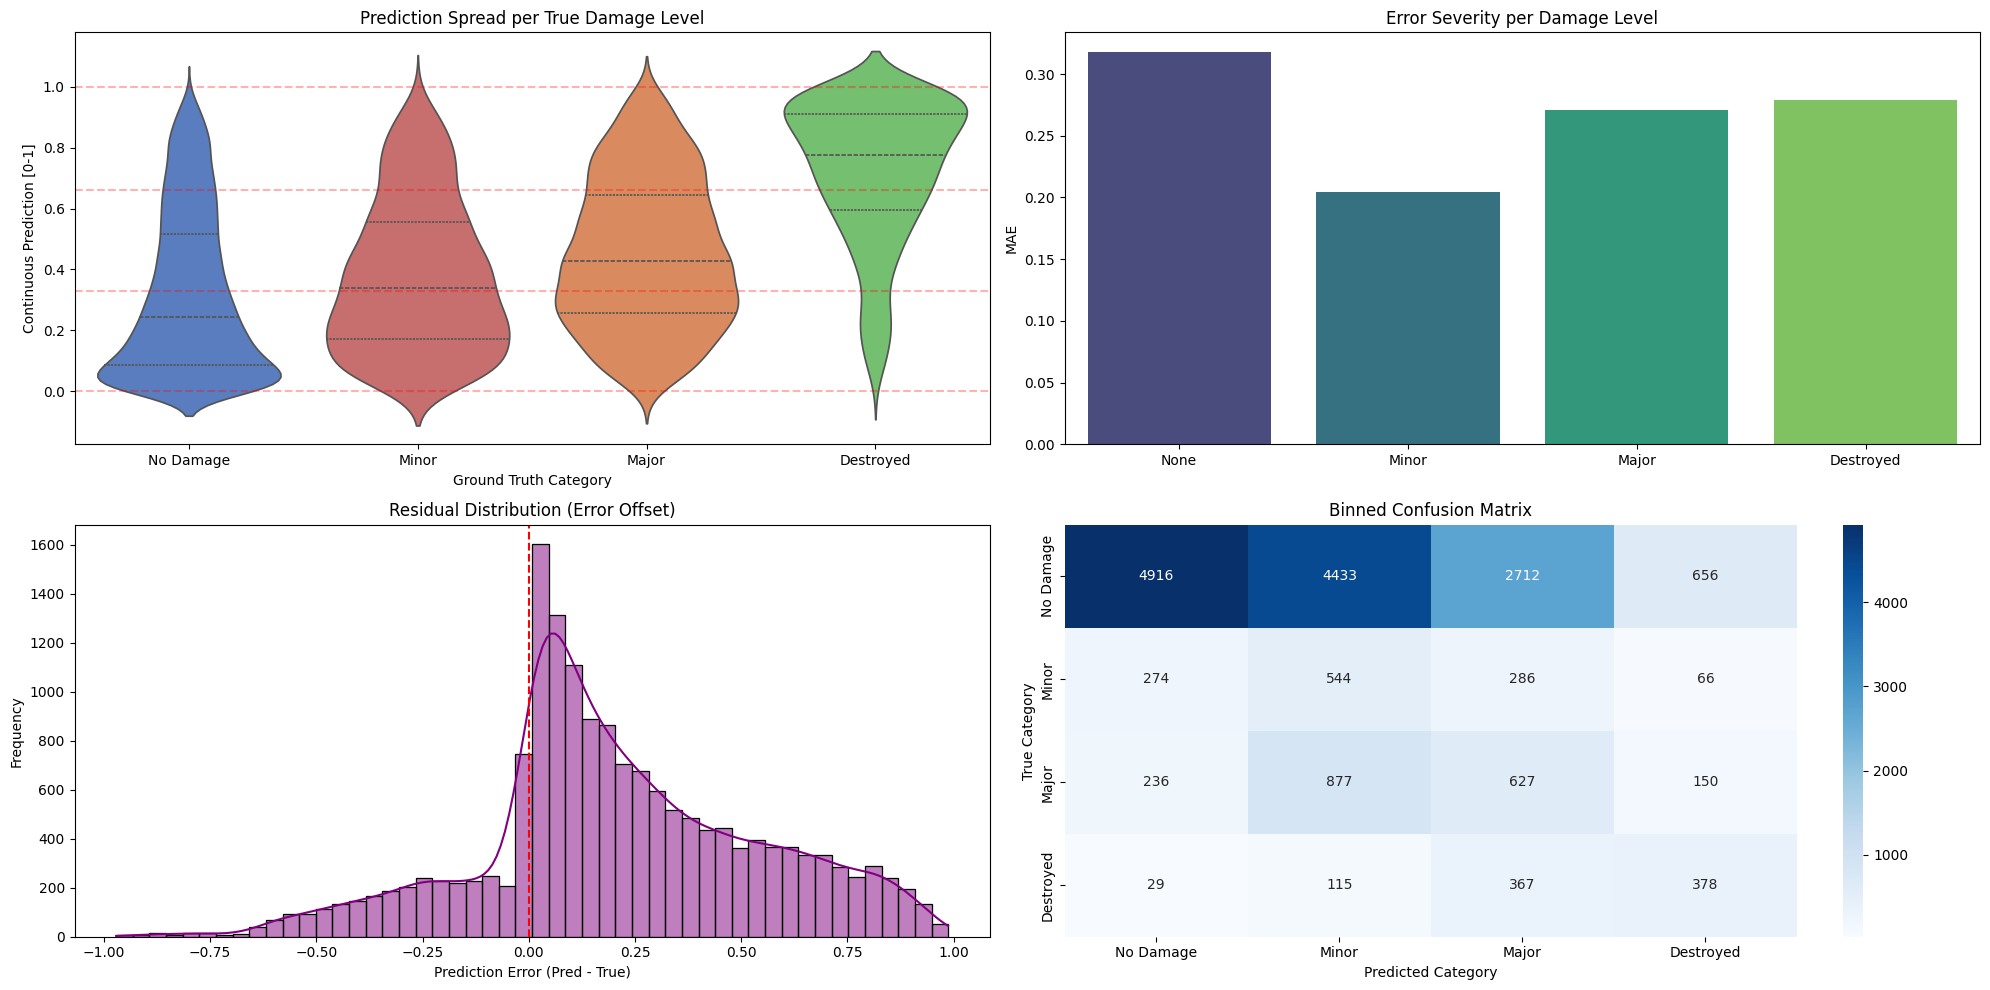

In [ ]:
plt.figure(figsize=(20, 10))

order = ['No Damage', 'Minor', 'Major', 'Destroyed']

plt.subplot(2, 2, 1)
sns.violinplot(x=target_labels, y=all_preds, order=order, palette='muted', inner="quartile", hue=target_labels, legend=False)

for val in [0.0, 0.33, 0.66, 1.0]:
    plt.axhline(val, color='red', linestyle='--', alpha=0.3)
plt.title("Prediction Spread per True Damage Level")
plt.ylabel("Continuous Prediction [0-1]")
plt.xlabel("Ground Truth Category")

plt.subplot(2, 2, 2)
class_errors = {val: [] for val in [0.0, 0.33, 0.66, 1.0]}
for p, t in zip(all_preds, all_targets):
    target_key = round(float(t), 2)
    if target_key in class_errors:
        class_errors[target_key].append(abs(p - t))

labels = ['None', 'Minor', 'Major', 'Destroyed']
mae_vals = [np.mean(class_errors[k]) if class_errors[k] else 0 for k in [0.0, 0.33, 0.66, 1.0]]
sns.barplot(x=labels, y=mae_vals, palette='viridis', hue=labels, legend=False)
plt.title("Error Severity per Damage Level")
plt.ylabel("MAE")

plt.subplot(2, 2, 3)
residuals = all_preds - all_targets
sns.histplot(residuals, bins=50, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution (Error Offset)")
plt.xlabel("Prediction Error (Pred - True)")
plt.ylabel("Frequency")

plt.subplot(2, 2, 4)
cm = confusion_matrix(target_labels, pred_labels, labels=order)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=order, yticklabels=order)
plt.title("Binned Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")

plt.tight_layout()
plt.show()

# UNBALANCED

In [ ]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import models, transforms
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, f1_score, confusion_matrix
from scipy.stats import spearmanr

from resnet import SiameseLazyDataset, get_metadata, DEVICE, DAMAGE_MAP, PATCH_SIZE

class SiameseResNet(torch.nn.Module):
    def __init__(self):
        super(SiameseResNet, self).__init__()
        resnet = models.resnet34(weights=None)
        self.backbone = torch.nn.Sequential(*(list(resnet.children())[:-1]))
        
        self.regressor = torch.nn.Sequential(
            torch.nn.Linear(512 * 4, 512), 
            torch.nn.BatchNorm1d(512),
            torch.nn.SiLU(),
            torch.nn.Dropout(0.4),
            torch.nn.Linear(512, 128),
            torch.nn.SiLU(),
            torch.nn.Linear(128, 1),
            torch.nn.Sigmoid()
        )

    def forward(self, pre, post):
        f_pre = self.backbone(pre).view(pre.size(0), -1)
        f_post = self.backbone(post).view(post.size(0), -1)
        f_diff = torch.abs(f_post - f_pre)
        f_prod = f_pre * f_post 
        combined = torch.cat((f_pre, f_post, f_diff, f_prod), dim=1)
        return self.regressor(combined)

WEIGHTS_PATH = 'best_siamese_resnet.pth'
LIMIT_IMAGES = 1200  

print(f"🚀 Initializing Analysis on {DEVICE}...")

metadata, _ = get_metadata(limit=LIMIT_IMAGES)

model = SiameseResNet().to(DEVICE)
try:
    state_dict = torch.load(WEIGHTS_PATH, map_location=DEVICE)
    model.load_state_dict(state_dict)
    print("✅ Weights loaded successfully.")
except FileNotFoundError:
    print(f"❌ Error: {WEIGHTS_PATH} not found. Ensure training completed first.")

model.eval()

🚀 Initializing Analysis on xpu...


Scanning Metadata: 100%|██████████| 1200/1200 [00:02<00:00, 574.63it/s]


📈 Dataset Imbalance: {0.0: 29247, 0.33: 3335, 0.66: 3706, 1.0: 2368}
✅ Weights loaded successfully.


SiameseResNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [ ]:
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ds = SiameseLazyDataset(metadata, transform=val_transform)
loader = DataLoader(ds, batch_size=16, shuffle=False, num_workers=4)

all_preds = []
all_targets = []

with torch.no_grad():
    for pre, post, target in tqdm(loader, desc="Running Inference"):
        pre, post = pre.to(DEVICE), post.to(DEVICE)
        out = model(pre, post).cpu().numpy().flatten()
        all_preds.extend(out)
        all_targets.extend(target.numpy().flatten())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

Running Inference: 100%|██████████| 2416/2416 [07:45<00:00,  5.19it/s]


In [ ]:
r2 = r2_score(all_targets, all_preds)
mae = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
rho, _ = spearmanr(all_targets, all_preds)

def get_label_name(val):
    if val < 0.165: return "No Damage"
    if val < 0.495: return "Minor"
    if val < 0.825: return "Major"
    return "Destroyed"

target_labels = [get_label_name(t) for t in all_targets]
pred_labels = [get_label_name(p) for p in all_preds]

binned_f1_macro = f1_score(target_labels, pred_labels, average='macro')
binned_f1_weighted = f1_score(target_labels, pred_labels, average='weighted')

print("\n" + "="*50)
print(f"{'REGRESSION METRIC':<25} | {'VALUE':<10}")
print("-" * 50)
print(f"{'R-squared (Global)':<25} | {r2:.4f}")
print(f"{'Mean Absolute Error':<25} | {mae:.4f}")
print(f"{'Root Mean Square Error':<25} | {rmse:.4f}")
print(f"{'Spearman Correlation':<25} | {rho:.4f}")
print("-" * 50)
print(f"{'BINNED CLASSIFICATION':<25} | {'VALUE':<10}")
print(f"{'Macro-F1 Score':<25} | {binned_f1_macro:.4f}")
print(f"{'Weighted-F1 Score':<25} | {binned_f1_weighted:.4f}")
print("="*50)


REGRESSION METRIC         | VALUE     
--------------------------------------------------
R-squared (Global)        | 0.8513
Mean Absolute Error       | 0.0484
Root Mean Square Error    | 0.1151
Spearman Correlation      | 0.7305
--------------------------------------------------
BINNED CLASSIFICATION     | VALUE     
Macro-F1 Score            | 0.8083
Weighted-F1 Score         | 0.9005


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

order = ['No Damage', 'Minor', 'Major', 'Destroyed']
os.makedirs('unbalanced_plots', exist_ok=True) # Create folder for cleanliness

plt.figure(figsize=(10, 6))
sns.violinplot(x=target_labels, y=all_preds, order=order, palette='muted', inner="quartile", hue=target_labels, legend=False)
for val in [0.0, 0.33, 0.66, 1.0]:
    plt.axhline(val, color='red', linestyle='--', alpha=0.3)
plt.title("Prediction Spread per True Damage Level")
plt.ylabel("Continuous Prediction [0-1]")
plt.savefig('unbalanced_plots/prediction_violin.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(10, 6))
class_errors = {0.0: [], 0.33: [], 0.66: [], 1.0: []}
for p, t in zip(all_preds, all_targets):
    target_key = round(float(t), 2)
    if target_key in class_errors:
        class_errors[target_key].append(abs(p - t))

mae_vals = [np.mean(class_errors[k]) if class_errors[k] else 0 for k in [0.0, 0.33, 0.66, 1.0]]
sns.barplot(x=order, y=mae_vals, palette='viridis', hue=order, legend=False)
plt.title("Error Severity per Damage Level")
plt.ylabel("Mean Absolute Error")
plt.savefig('unbalanced_plots/mae_by_class.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(10, 6))
residuals = all_preds - all_targets
sns.histplot(residuals, bins=50, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution (Error Offset)")
plt.xlabel("Prediction Error (Pred - True)")
plt.savefig('unbalanced_plots/residuals_hist.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(8, 7))
cm = confusion_matrix(target_labels, pred_labels, labels=order)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=order, yticklabels=order)
plt.title("Binned Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.savefig('unbalanced_plots/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

print("✅ All plots saved to the 'unbalanced_plots' directory.")

✅ All plots saved to the 'unbalanced_plots' directory.
